In [3]:
hok_path = '/content/drive/MyDrive/UTY/Semester 7/Pemrosesan Teks /tri-gram/hok_reviews_clean_3-gram.csv'
mlbb_path = '/content/drive/MyDrive/UTY/Semester 7/Pemrosesan Teks /tri-gram/mlbb_reviews_clean_3-gram.csv'

In [4]:
import pandas as pd

df_hok = pd.read_csv(hok_path)
df_mlbb = pd.read_csv(mlbb_path)

## Tokenisasi




In [5]:
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

nltk.download('punkt_tab', quiet=True)

def tokenize_and_ngram(review, n=3):
  """Tokenizes a given review string and generates n-grams."""
  if pd.isna(review):
    return []
  tokens = word_tokenize(review)
  if len(tokens) < n:
      return []
  return list(ngrams(tokens, n))

df_hok['tokenized'] = df_hok['content_clean'].apply(lambda x: tokenize_and_ngram(x, n=2))
df_mlbb['tokenized'] = df_mlbb['content_clean'].apply(lambda x: tokenize_and_ngram(x, n=2))

# Filtering

In [6]:
import re

def filter_tokens(tokens):
    """Filters out non-alphabetic characters and repeated letters from a list of token tuples."""
    filtered_tokens = []
    # Regex to match any character that is NOT a letter (a-z, A-Z) or a space
    pattern = re.compile(r'[^a-zA-Z\s]+')
    # Regex to match 3 or more repeating characters
    repeat_pattern = re.compile(r'(.)\1{2,}')

    if not isinstance(tokens, list):
        return [] # Handle cases where input is not a list

    for token_tuple in tokens:
        filtered_tuple = []
        for token in token_tuple:
            if isinstance(token, str): # Ensure the element is a string
                # Remove non-alphabetic characters
                cleaned_token = pattern.sub('', token)
                # Remove repeating characters
                cleaned_token = repeat_pattern.sub(r'\1', cleaned_token)
                if cleaned_token: # Keep only non-empty strings after filtering
                    filtered_tuple.append(cleaned_token)
        if filtered_tuple: # Keep only non-empty tuples after filtering
            filtered_tokens.append(tuple(filtered_tuple)) # Convert back to tuple

    return filtered_tokens

df_hok['filtered_tokens'] = df_hok['tokenized'].apply(filter_tokens)
df_mlbb['filtered_tokens'] = df_mlbb['tokenized'].apply(filter_tokens)

# Stemming

In [7]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [8]:
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    """Stems a list of token tuples."""
    stemmed_tuples = []
    if isinstance(tokens, list):
        for token_tuple in tokens:
            stemmed_tuple = tuple(stemmer.stem(token) for token in token_tuple if isinstance(token, str))
            if stemmed_tuple:
                stemmed_tuples.append(stemmed_tuple)
    return stemmed_tuples

df_hok['stemmed_tokens'] = df_hok['filtered_tokens'].apply(stem_tokens)
df_mlbb['stemmed_tokens'] = df_mlbb['filtered_tokens'].apply(stem_tokens)

# Slang Words

In [9]:
slang_words = {
      'bagu':'bagus',
      'bgt':'banget',
      'gak':'tidak',
      'gk':'tidak',
      'gw':'aku',
      'trus':'terus',
      'monton':'moonton',
      'montoon':'moonton',
      'maen':'main',
      'leg':'lag',
      'ngelag':'lag',
      'ngeleg':'lag',
      'klo':'kalau',
      'tim':'team',
      'ga':'tidak',
      'lu':'kamu',
      'gem':'game',
      'gua':'aku',
      'saya':'aku',
      'g':'tidak',
      'kalo':'kalau',
      'gin':'game',
      'yg':'yang',
      'ngelek':'lag',
      'sering lag':'lag',
      'kayak':'seperti',
      'kaya':'seperti',
      'geme':'game',
      'i':'aku',
      'ny':'nya',
      'gamenya':'game',
      'x':'kali',
      'dark':'gelap',
      'bener':'benar',
      'benerin':'rusak',
      'dibenerin':'rusak',
      'beneran':'serius',
      'gabener':'salah',
      'benerr':'benar',
      'benerlah':'benar',
      'bbenerin':'rusak',
      'benere':'benar',
      'benerlaa':'benar',
      'ngasih':'beri',
      'udh':'sudah',
      'ni':'ini',
      'karna':'karena',
      'min':'minimal',
      'burik':'buruk',
      'sampe':'sampai',
      'pake':'pakai',
      'drak':'gelap',
      'emang':'memang',
      'dikit':'sedikit',
      'dikitlh':'sedikit',
      'cuman':'hanya',
      'dah':'sudah',
      'berik':'beri',
      'ajha':'aja',
      'kek':'seperti',
      'lapor':'report',
      'laporin':'report',
      'ngelaporin':'report',
      'reportnya':'report',
      'direport':'report',
      'ngreport':'report',
      'cobain':'coba',
      'coban':'coba',
      'temen':'teman',
      'temenya':'teman',
      'temanteman':'teman',
      'temantemanku':'teman',
      'jagoteman':'jago',
      'doang':'hanya',
      'drag':'gelap',
      'system':'sistem',
      'dpt':'dapat',
      'tetep':'tetap',
      'stress':'stres',
      'nggak':'tidak',
      'skil':'skill',
      'skillnya':'skill',
      'skills':'skill',
      'bosok':'buruk',
      'bobrok':'buruk',
      'anjlok':'buruk',
      'toksik':'buruk',
      'kalok':'kalau',
      'ok':'oke',
      'okey':'oke',
      'gue':'aku',
      'baguss':'bagus',
      'anda':'kamu',
      'terimakasi':'terimakasih',
      'terima':'terimakasih',
      'makasihh':'terimakasih',
      'trjmakasih':'terimakasih',
      'trimakasih':'terimakasih',
      'makasih':'terimakasih',
      'tpi':'tapi',
      'aj':'aja',
      'jdi':'jadi',
      'ampas':'buruk',
      'woi':'buruk',
      'tp':'tapi',
      'matchmakingnya':'matchmaking',
      'bet':'banget',
      'ytim':'yatim',
      'sangatt':'sangat',
      'inisangat':'sangat'
}

def replace_slang(tokens, slang_dict):
    """Replaces slang words in a list of tokens using a slang dictionary."""
    return [slang_dict.get(token, token) for token in tokens]

df_hok['slang_replaced'] = df_hok['stemmed_tokens'].apply(lambda x: replace_slang(x, slang_words))
df_mlbb['slang_replaced'] = df_mlbb['stemmed_tokens'].apply(lambda x: replace_slang(x, slang_words))

# Stopwords

In [10]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set([
    'yang', 'nya', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah', 'itu', 'aja', 'tapi', 'sih', 'dapet', 'tiap', 'saat', 'tapi', 'kasih', 'jaring',
    'pas', 'mulu', 'dulu', 'ini', 'saya', 'kami', 'kita', 'anda', 'mereka', 'atau', 'juga', 'tidak', 'eh', 'nyeselin', 'yah', 'ya', 'nah', 'kok', 'lagi', 'udah',
    'jadi', 'karena', 'agar', 'supaya', 'moonton', 'sebagai', 'oleh', 'terhadap', 'tentang', 'bahwa', 'hanya', 'saja', 'masih', 'telah', 'akan', 'bisa', 'dapat',
    'harus', 'boleh', 'mau', 'ingin', 'perlu', 'nya','game', 'hp', 'gamenya', 'tara', 'ml', 'hok', 'ada', 'aku', 'main', 'hero', 'rank', 'team', 'kalau', 'apa',
    'player', 'terus', 'sama', 'lah', 'nge', 'matchmaking', 'match', 'malah', 'download', 'orang', 'padahal', 'making', 'tau', 'plis', 'tencent', 'malah', 'buat',
    'udah', 'seperti', 'bikin', 'sering', 'kali', 'tiap', 'tiba', 'sekali', 'solo', 'data', 'kok', 'ku', 'saat', 'honor', 'of', 'kings', 'legend', 'mobile', 'dong',
    'belah', 'hari', 'tuh', 'kan', 'in', 'mlbb', 'soal', 'pun', 'login', 'waktu', 'kata', 'moba', 'mode', 'pakai', 'the', 'kalian', 'lane', 'sistem', 'nih', 'war',
    'simpan', 'fitur', 'ketika', 'awal', 'pick', 'cara', 'ama', 'gilir', 'nama', 'map', 'to', 'masak', 'gameplay', 'beli', 'loh', 'kesini', 'sini', 'apalagi', 'turut',
    'deh', 'memang', 'kembali', 'baca', 'bakal', 'temu', 'daripada', 'rasa', 'is', 'a', 'si', 's', 'jam', 'tahun', 'liat', 'depan', 'la', 'sangat', 'kamu'
])

def remove_stopwords_nltk(tokens):
    """Removes stopwords from a list of tokens using NLTK's stopword list."""
    if not isinstance(tokens, list):
        return [] # Return empty list for non-list inputs
    return [token for token in tokens if token not in stop_words]

df_hok['stopwords_removed'] = df_hok['slang_replaced'].apply(remove_stopwords_nltk)
df_mlbb['stopwords_removed'] = df_mlbb['slang_replaced'].apply(remove_stopwords_nltk)

In [11]:
df_hok.to_csv(hok_path, index=False)
df_mlbb.to_csv(mlbb_path, index=False)

# Wordclouds

In [12]:
!pip install wordcloud

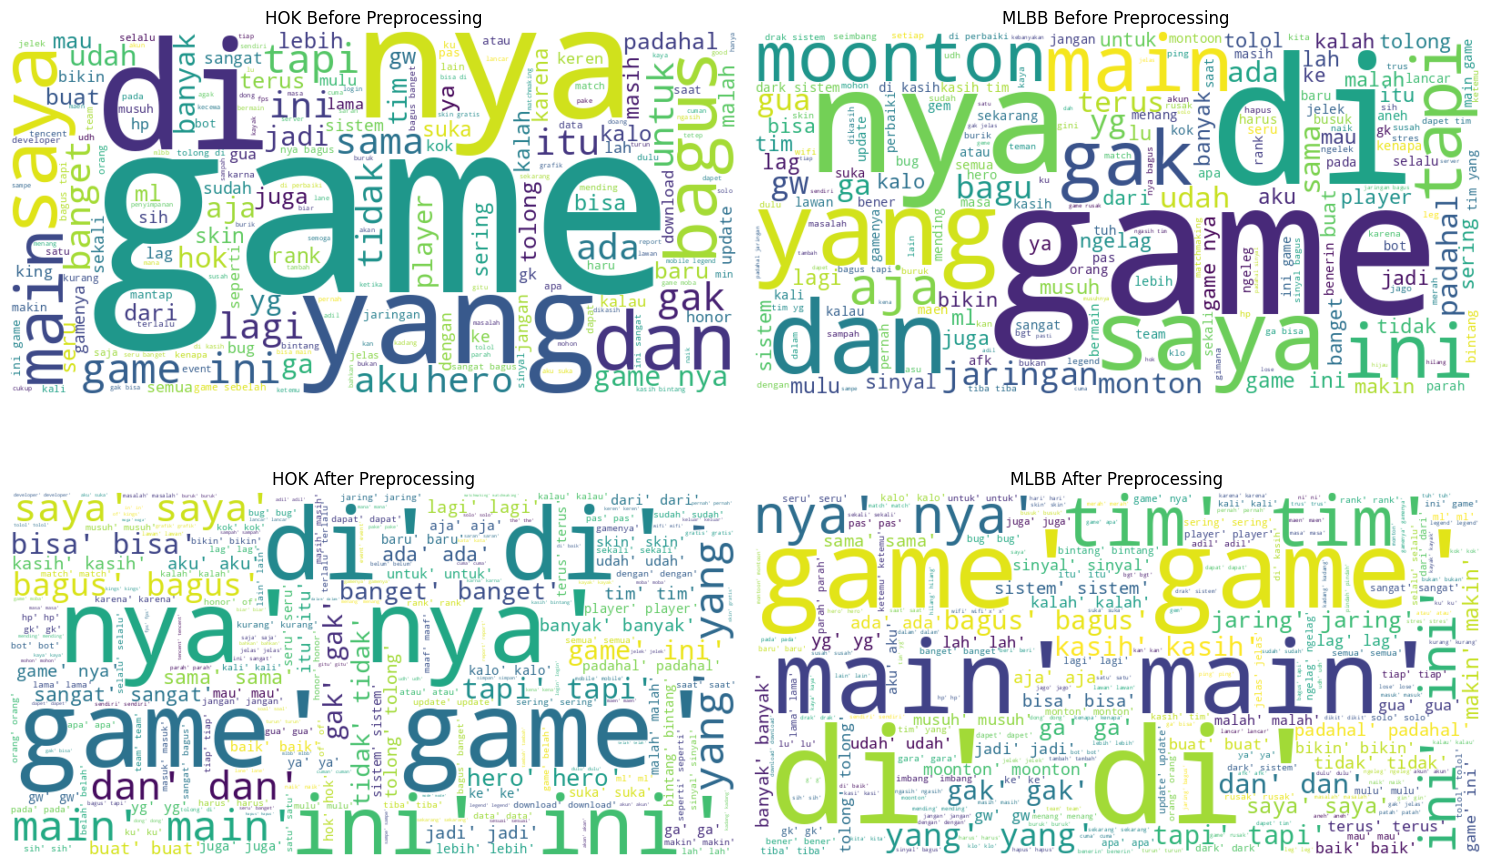

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

hok_before = ' '.join(df_hok['content_clean'].astype(str))
# Modify this line to join tokens within each tuple before joining all tuples
hok_after = ' '.join([' '.join(map(str, tokens)) for tokens in df_hok['stopwords_removed']])
mlbb_before = ' '.join(df_mlbb['content_clean'].astype(str))
# Modify this line to join tokens within each tuple before joining all tuples
mlbb_after = ' '.join([' '.join(map(str, tokens)) for tokens in df_mlbb['stopwords_removed']])

def generate_wordcloud(text):
    """Generates a word cloud from a text string."""
    return WordCloud(width=800, height=400, background_color='white').generate(text)

# Generate word clouds
wordcloud_hok_before = generate_wordcloud(hok_before)
wordcloud_mlbb_before = generate_wordcloud(mlbb_before)
wordcloud_hok_after = generate_wordcloud(hok_after)
wordcloud_mlbb_after = generate_wordcloud(mlbb_after)

# Display word clouds in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].imshow(wordcloud_hok_before, interpolation='bilinear')
axes[0, 0].axis('off')
axes[0, 0].set_title('HOK Before Preprocessing')

axes[0, 1].imshow(wordcloud_mlbb_before, interpolation='bilinear')
axes[0, 1].axis('off')
axes[0, 1].set_title('MLBB Before Preprocessing')

axes[1, 0].imshow(wordcloud_hok_after, interpolation='bilinear')
axes[1, 0].axis('off')
axes[1, 0].set_title('HOK After Preprocessing')

axes[1, 1].imshow(wordcloud_mlbb_after, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('MLBB After Preprocessing')

plt.tight_layout()
plt.show()